# Optimization for AI Project - Deiana

For this project, we will explore and try to design a GA algorithm to automatically synthesize FIR filters according to a desired frequency response. We will start with a baseline simplified proof of concept, and then we will take inspiration from a couple of papers to produce more useful and realistic results.

A digital FIR filter is characterized by the following transfer function: $H(s)=\sum^{N}_{n=0}a_nz^{-n}$, where $N$ is the order of the filter, and $a_n$ are
defined as the filter coefficients.

As we can see, an individual in this case is simply a finite vector of real values, which allows us to inherit all the literature about real-valued GAs. In reality,
digital FIR filters are designed to be implemented in hardware. This presents us with a couple of challenges, namely that hardware costs increase with the order of the filter and the way it's implemented.
As we will later see, a particular ternary encoding called CSD is preferred, as it allows to automatically synthesize a filter from the provided genome and saves up on circuit complexity.
 This, in turn, means that the real-valued GAs, which are quite simple to implement in software, are not desirable for real-world FIR filter design. Nonetheless, precisely because of its simplicity,
 we will first implement a real-valued version of the GA as a baseline, and compare it wrt. execution speed, convergence speed, and fitness with the algorithms proposed in the papers.

## Real-valued GA baseline

Before we implement the techniques proposed in the papers, it could be interesting to create a simple proof of concept at a higher level. We will implement the classic GA structure, and encode the individuals as simple vectors of real numbers.

The GA will be implemented as follows:
- Chromosome: $x=(x_1,…,x_n)$, where $x_i \in [-1, 1] \subset \mathbb{R}, \forall i \in {0, ..., n}$
- Init: Uniform sampling
- Mutation: Gaussian
- Crossover: Two-point crossover, Discrete recombination
- Selection: Roulette Wheel, Tournament
- Fitness: Minimax, LMS, MSE

We will use the signal library from Scipy for calculating the frequency response of each individual, together with numpy. For everything else, standard python is enough to implement the GA.

### Implementation

In [175]:
import random, bisect
import numpy as np
from scipy.signal import freqz

In [176]:
def sample_individual(order):
    individual = []
    for _ in range(order):
        individual.append(random.uniform(-1, 1))
    return individual

In [177]:
def init_pop(order, n_pop):
    return [sample_individual(order) for _ in range(n_pop)]

In [178]:
def mut(individual, p=0.01):
    mutated = []
    for coeff in individual:
        if random.random() < p:
            mutated.append(coeff + random.gauss())
        else:
            mutated.append(coeff)
    return mutated

In [179]:
def twopoint_cross(parent1, parent2):
    indexes = random.sample(range(1, len(parent1)-1), 2)
    indexes.sort()
    return parent1[:indexes[0]] + parent2[indexes[0]:indexes[1]] + parent1[indexes[1]:]

def recomb_cross(parent1, parent2):
    child = []
    for p, q in zip(parent1, parent2):
        a = random.uniform(0, 1)
        child.append(a*p + (1-a)*p)
    return child

def cross(parent1, parent2, strategy=twopoint_cross):
    return strategy(parent1, parent2)

In [180]:
def minimax_error(individual, target):
    wi, Hi = np.array(freqz(individual))
    Ht = np.array([target(w) for w in wi])
    error = max(np.abs(np.abs(Ht) - np.abs(Hi)))
    return error

def lms_error(individual, target):
    wi, Hi = np.array(freqz(individual))
    Ht = np.array([target(w) for w in wi])
    error = np.sqrt(np.sum(np.power(np.abs(Ht) - np.abs(Hi), 2)))
    return error

def mse(individual, target):
    wi, Hi = np.array(freqz(individual))
    Ht = np.array([target(w) for w in wi])
    error = np.average(np.sum(np.power(np.abs(Ht) - np.abs(Hi), 2)))
    return error

def minimax_fit(individual, target):
    return 1/minimax_error(individual, target)

def lms_fit(individual, target):
    return 1/lms_error(individual, target)

def mse_fit(individual, target):
    return 1/mse(individual, target)

In [181]:
def roulette_selection(pop, n_pop, fitness, target):
    # Compute fitness values once
    fvals = [fitness(ind, target) for ind in pop]
    tot = sum(fvals)
    # Build cumulative distribution
    cum = []
    s = 0.0
    for fv in fvals:
        s += fv
        cum.append(s)
    newpop = []
    for _ in range(n_pop):
        r = random.random() * tot  # r ∈ [0, tot)
        idx = bisect.bisect_left(cum, r)
        newpop.append(pop[idx])
    return newpop

def tournament_selection(pop, n_pop, fitness, target, k=3):
    newpop = []
    while len(newpop) < n_pop:
        contestants = random.choices(population=pop, k=k)
        contestants.sort(key=lambda x : fitness(x, target), reverse=True)
        newpop.append(contestants[0])
    return newpop

def selection(pop, n_pop, fitness, target, strategy=roulette_selection):
    return strategy(pop, n_pop, fitness, target)

In [182]:
def GA(n_pop, generations, order, target, fitness):
    pop = []
    best = []
    # Population initialization
    pop = init_pop(order, n_pop)
    for _ in range(generations):
        best.append(max(pop, key=lambda x: fitness(x, target)))
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop)-1)]
            parent2 = pop[random.randint(0, len(pop)-1)]
            child1 = mut(cross(parent1, parent2))
            child2 = mut(cross(parent2, parent1))
            pop.append(child1)
            pop.append(child2)
        pop = selection(pop, n_pop, fitness, target)
    return best

### Testing "classic" FIR filters

In [183]:
import matplotlib.pyplot as plt

In [184]:
n_pop = 100
generations = 100
order = 4

#### 1. Ideal high-pass filter

In [185]:
def target(w):
    return 1 if w >= 1.5 else 0

In [186]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit)
best_lms = GA(n_pop, generations, order, target, lms_fit)
best_mse = GA(n_pop, generations, order, target, mse_fit)

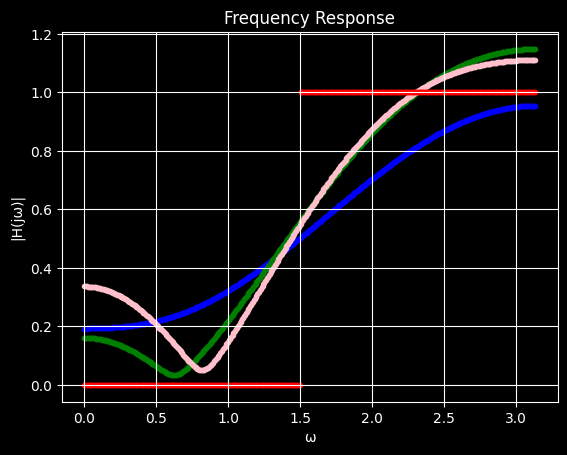

In [187]:
w1, H1 = freqz(best_minimax[-1])
w2, H2 = freqz(best_lms[-1])
w3, H3 = freqz(best_mse[-1])
wt, Ht = w1, np.array([target(w) for w in w1])
plt.scatter(w1, abs(H1), c='blue', marker='.')
plt.scatter(w2, abs(H2), c='green', marker='.')
plt.scatter(w3, abs(H3), c='pink', marker='.')
plt.scatter(wt, abs(Ht), c='red', marker='.')
plt.xlabel("ω")
plt.ylabel("|H(jω)|")
plt.title("Frequency Response")
plt.grid(True)
plt.show()